Ce projet vise à analyser les ventes mondiales de jeux vidéo à partir du dataset VGChartz 2024.

**Objectif** : Prédire les ventes totales d'un jeu en fonction de sa plateforme, son genre et son éditeur.

**Dataset** : vgchartz-2024.csv — données de ventes mondiales de jeux vidéo.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Etape 1** : Chargement du dataset et premier nettoyage des données

In [14]:
data = pd.read_csv("vgchartz-2024.csv")
data.drop(columns=['img'], inplace = True)
data

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11,2019-01-28
64012,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64013,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64014,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28,2019-02-24


In [15]:
data.replace(['NaN', 'unknown', 'null'], np.nan, inplace = True);
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce').dt.year.astype('Int64')
data['last_update'] = pd.to_datetime(data['last_update'], errors='coerce').dt.year.astype('Int64')
data.rename(columns={'release_date' : 'release_year', 'last_update' : 'update_year'}, inplace=True)
data


,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_year,update_year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013,<NA>
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014,2018
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002,<NA>
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013,<NA>
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016,2019
64012,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020,2020
64013,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020,2020
64014,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019,2019


**Etape 2** : On essaie de repérer des insights clés

En regardant le diagramme en barres des ventes totales en fonction de l'éditeur, on remarque par exemple que c'est Activision qui a le plus vendu

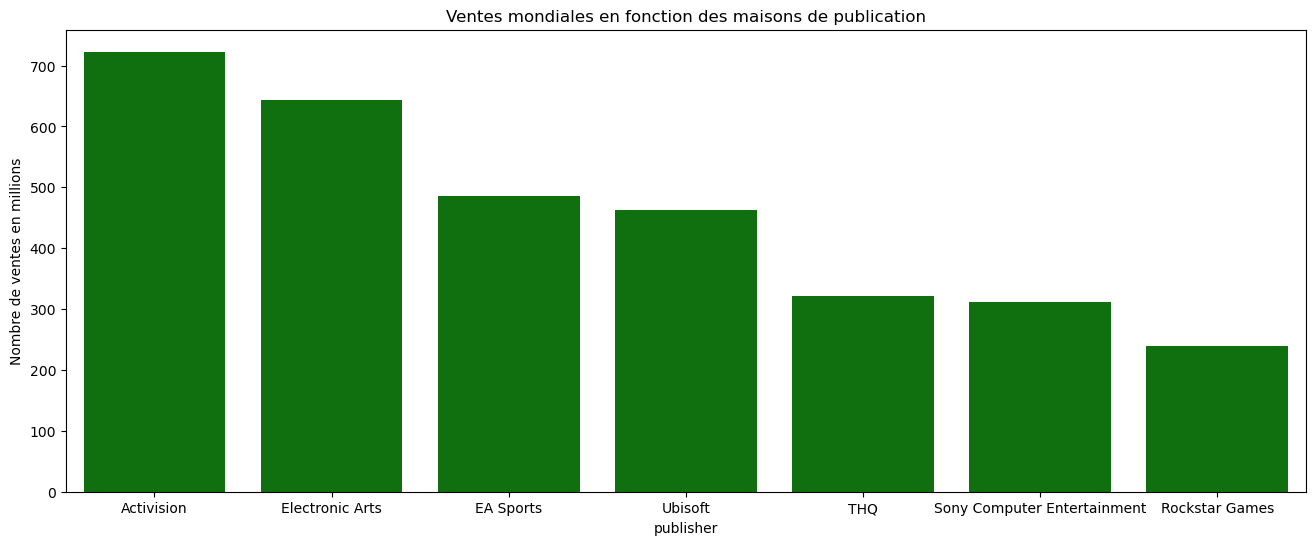

In [16]:
sales_publishers = data.groupby("publisher")["total_sales"].sum().sort_values(ascending=False).head(7)
plt.figure(figsize=(16, 6))
plt.title('Ventes mondiales en fonction des maisons de publication')
plt.ylabel('Nombre de ventes en millions')
sns.barplot(
    x=sales_publishers.index,
    y=sales_publishers.values,
    color='green'
)
plt.show()

Par ailleurs le diagramme en barres des ventes totales en fonction du genre révèle que c'est le sport qui domine en termes de ventes mondiales

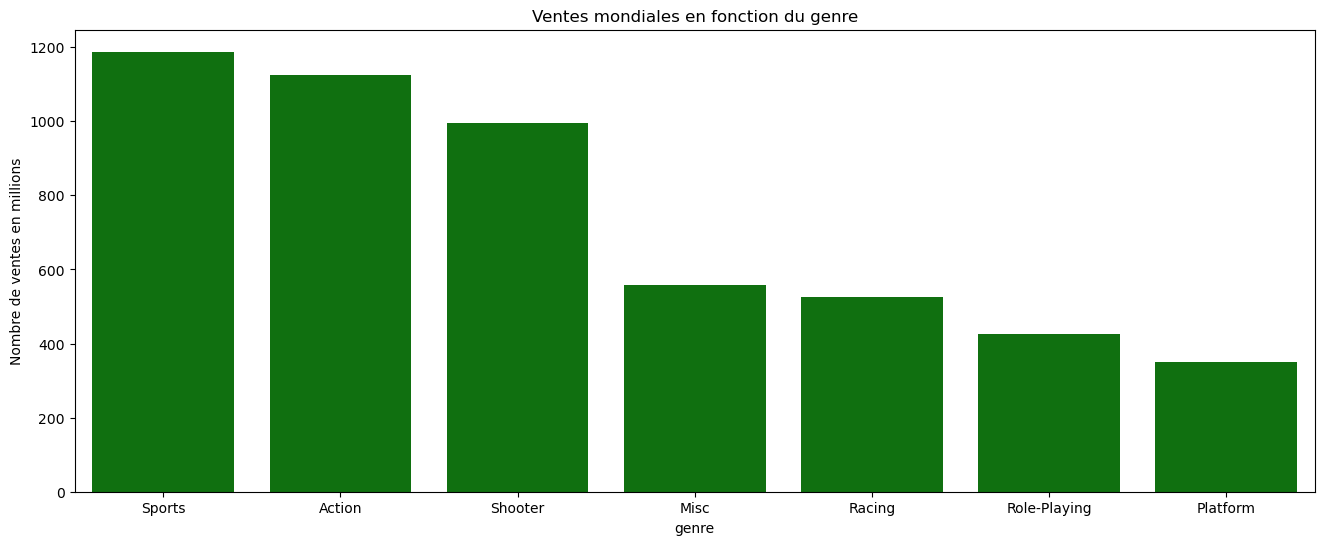

In [17]:
sales_genre = data.groupby("genre")["total_sales"].sum().sort_values(ascending=False).head(7)
plt.figure(figsize=(16, 6))
plt.title('Ventes mondiales en fonction du genre')
plt.ylabel('Nombre de ventes en millions')
sns.barplot(
    x=sales_genre.index,
    y=sales_genre.values,
    color='green'
)
plt.show()

Enfin le diagramme en barres des ventes totales en fonction de la plateforme révèle que playstation est la plateforme qui fait le plus de vente au niveau mondial

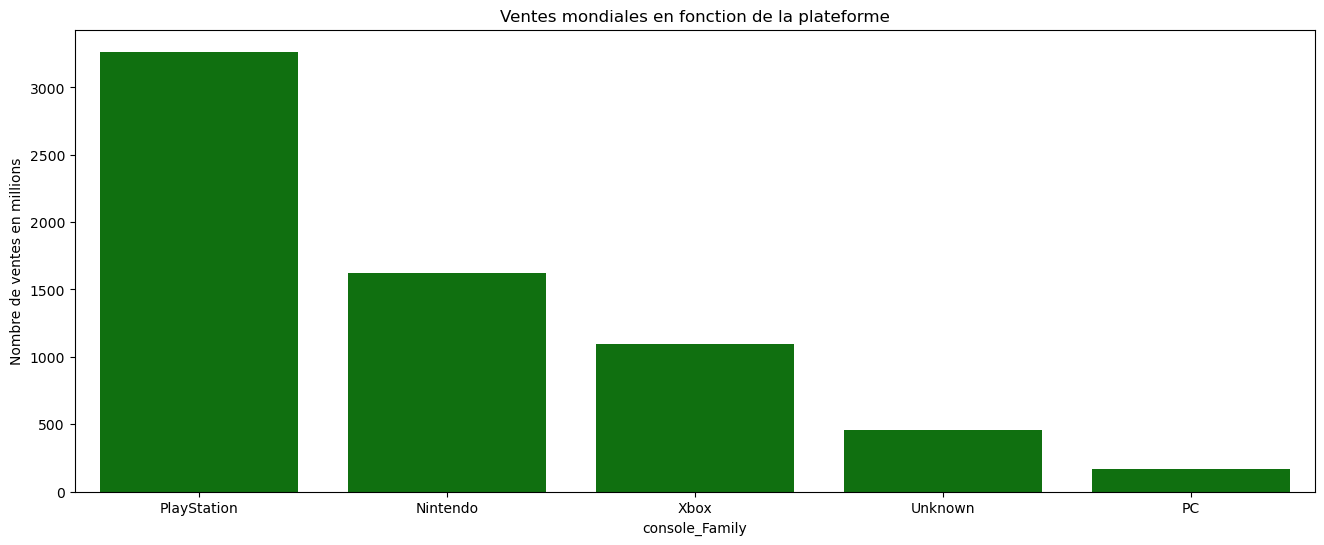

In [18]:
def console_family(console):
    if str(console).startswith("PS"):
        return "PlayStation"
    elif console in ["XB", "X360"]:
        return "Xbox"
    elif console in ["Wii", "WiiU", "DS", "3DS", "N64", "GC", "SNES", "NES", "GB", "GBA"]:
        return "Nintendo"
    elif console == "PC":
        return "PC"
    else:
        return "Unknown"

data["console_Family"] = data["console"].apply(console_family)

sales_platform = data.groupby("console_Family")["total_sales"].sum().sort_values(ascending=False).head(7)
plt.figure(figsize=(16, 6))
plt.title('Ventes mondiales en fonction de la plateforme')
plt.ylabel('Nombre de ventes en millions')
sns.barplot(
    x=sales_platform.index,
    y=sales_platform.values,
    color='green'
)
plt.show()

In [19]:
sales_publishers = data.groupby("publisher")["total_sales"].sum().reset_index().sort_values(by='total_sales', ascending=False).head(7)
sales_publishers.to_csv("sales_publishers.csv", index=False)
sales_genre.to_csv("sales_genre.csv", index=False)
sales_platform.to_csv("sales_platform.csv", index=False)

In [9]:
data.to_csv("data.csv", index=False)

In [20]:
data

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_year,update_year,console_Family
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013,<NA>,PlayStation
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014,2018,PlayStation
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002,<NA>,PlayStation
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013,<NA>,Xbox
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015,2018,PlayStation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016,2019,PC
64012,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020,2020,PlayStation
64013,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020,2020,Unknown
64014,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019,2019,Unknown


On se dirait donc que pour faire le plus de vente, il serait donc plus simple de sortir un jeu sur le sport, sur playstation et édité par Activision.

Cependant, notre analyse était juste globale, peut etre Activision domine juste car ils ont édité beaucoup de jeux. Il faudrait donc catégoriser et aller analyser les ventes moyennes en fonction du genre, de la plateforme et de l'éditeur, beaucoup d'analyse que l'on a pas forcément envie de faire, car je sais que tout comme moi, vous voulez gagner du temps

Alors pourquoi ne pas juste entrainer un modèle prédictif qui nous permettrait d'estimer le nombre de vente en fonction de ces 3 paramètres

**Etape 3** : Machine learning

J'ai du faire un deuxième nettoyage du dataset, transformer les données sous formes de texte en des combinaisons binaires que le modèle comprendrait.

Ensuite je l'ai entrainé, puis essayait de tester ce modèle avec 15% de mon dataset que j'avais gardé en réserve

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
data = data.dropna(subset=["total_sales"])
data["genre"] = data["genre"].fillna("Unknown")
data["publisher"] = data["publisher"].fillna("Unknown")
X =  pd.get_dummies(data[["genre", "console_Family", "publisher"]])
y = data['total_sales']
X

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20064\6805804.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["genre"] = data["genre"].fillna("Unknown")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20064\6805804.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["publisher"] = data["publisher"].fillna("Unknown")


,genre_Action,genre_Action-Adventure,genre_Adventure,genre_Board Game,genre_Education,genre_Fighting,genre_MMO,genre_Misc,genre_Music,genre_Party,...,publisher_eGames,publisher_fonfun,publisher_honeybee,publisher_iEntertainment Network,publisher_iMel,publisher_iWin,publisher_id Software,publisher_imageepoch Inc.,publisher_inXile Entertainment,publisher_responDESIGN
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18917,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18918,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18919,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18920,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [22]:
model = RandomForestRegressor()

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=33)

In [24]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_prediction = model.predict(X_test)

In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error,mean_absolute_error
print(f"MSE: {mean_squared_error(y_test, y_prediction)}")
print(f"MAE: {mean_absolute_error(y_test, y_prediction)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test[y_test > 0.1], y_prediction[y_test > 0.1])}")


MSE: 0.4077110717793355
MAE: 0.2808817849187629
MAPE: 0.8982571898468202


Algorithme : Random Forest Regressor (scikit-learn)
Split : 85% entraînement / 15% test
Encodage : One-hot encoding sur genre, plateforme et éditeur

J'obtiens comme résultats MSE: 0.4077110717793355 MAE: 0.2808817849187629 MAPE: 0.8982571898468202

Des scores assez corrects excepté le MAPE de 89%. En effet Le MAPE élevé est attendu sur ce type de données ,  les ventes varient de quelques milliers à plusieurs millions selon les jeux, ce qui rend la prédiction proportionnelle difficile sur les petits titres.


**Etape 4** : Test sorti de nulle part

J'ai simulé des jeux, de genre action, sur playstation , mais l'un édité par Rockstar Games et l'autre par Activision.

Celui édité par Rockstar est estimé à 5.7millions de ventes tandisque celui édité par Activision est estimé à 0.6 millions de ventes.

Notre doute sur la domination de Activision était donc fondé; dans le domaine du sport en tout cas, et de la plateforme playstation, Rockstar Game répond mieux en terme de vente que ce dernier quand même.

In [55]:
test = X_test.copy()
test = test.iloc[0:0]
test.loc[0] = [0] * len(test.columns)
test.loc[1] = [0] * len(test.columns)
test.loc[0, ["genre_Action", "publisher_Rockstar Games", "console_Family_PlayStation"]] = [1,1, 1]
test.loc[1, ["genre_Action", "publisher_Activision", "console_Family_PlayStation"]] = [1,1, 1]
test

,genre_Action,genre_Action-Adventure,genre_Adventure,genre_Board Game,genre_Education,genre_Fighting,genre_MMO,genre_Misc,genre_Music,genre_Party,...,publisher_eGames,publisher_fonfun,publisher_honeybee,publisher_iEntertainment Network,publisher_iMel,publisher_iWin,publisher_id Software,publisher_imageepoch Inc.,publisher_inXile Entertainment,publisher_responDESIGN
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [56]:
print(model.predict(test))

[5.7679287  0.60390075]


Si vous me lisez jusque là, je suis assez fier de ce petit projet, et j'espère apporter des analyses plus pertinentes sur des problématiques plus poussées et plus importantes la prochaine fois. Merci 